### Numpy em Opticas
---
#### Exemplo 1: Simulação de Atenuação Óptica em Fibras

No campo das comunicações ópticas, um dos conceitos fundamentais é o atenuamento do sinal, que é a perda de potência óptica à medida que a luz percorre uma fibra óptica. A atenuação pode ser modelada pela seguinte equação:

$$ P(z) = P_0⋅10^{-\frac{\alpha.z}{10}} $$

+ $P(z):$ Potência no ponto z ao longo da fibra.
+ $P0:$ Potência inicial do sinal na entrada da fibra.
+ $α:$ Coeficiente de atenuação (dB/km).
+ $z:$ Distância percorrida pelo sinal (em km).
  
>Neste exemplo, vamos simular a atenuação de um sinal óptico ao longo de diferentes distâncias de fibra óptica, considerando diferentes valores de $P_0$ (potência inicial) e $α$ (coeficiente de atenuação).


In [ ]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt

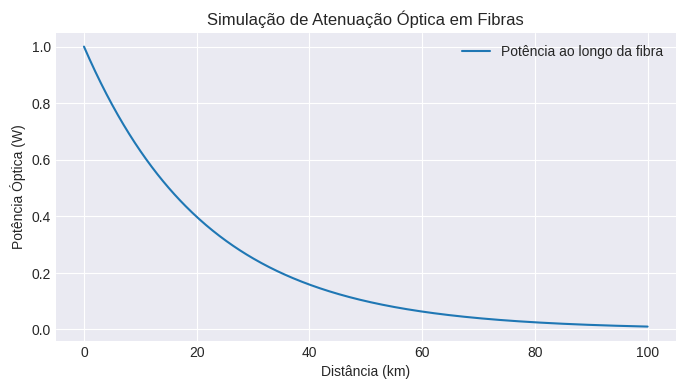

In [ ]:
# Parâmetros da simulação

P0 = 1.0  # Potência inicial do sinal (em Watts)
alpha = 0.2  # Coeficiente de atenuação (em dB/km)

# Distâncias em km (0 a 100 km)
# Iremos colocar 500 pontos ao longo da distância.
distancia = np.linspace(0, 100, 500)

# Calcular a potência ao longo da fibra usando a fórmula de atenuação
potencia_z = P0 * 10 ** (-alpha * distancia / 10)

# Configurações do gráfico
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(8, 4))

# Visualizando a potência ao longo da fibra
plt.plot(distancia, potencia_z, label=f'Potência ao longo da fibra')
plt.title('Simulação de Atenuação Óptica em Fibras')
plt.xlabel('Distância (km)')
plt.ylabel('Potência Óptica (W)')
plt.legend()
plt.show()


#### Exemplo 2:
Em __comunicações ópticas__, a dispersão cromática em uma fibra óptica faz com que diferentes comprimentos de onda (cores) de luz viajem a velocidades ligeiramente diferentes. Isso resulta em uma dispersão do pulso ao longo do tempo, à medida que o pulso percorre a fibra.

A __convolução__ pode ser usada para modelar esse fenômeno. O pulso transmitido pode ser convoluído com a resposta do sistema (fibra óptica com dispersão), resultando no pulso recebido que foi disperso.
> __Explicação Física:__
+ $Pulso$ $Transmitido:$ O pulso de luz que é enviado pela fonte de luz (por exemplo, um laser) tem uma forma definida, modelada aqui como um pulso gaussiano.
+ $Dispersão$ $Cromática$: Devido à dispersão cromática, diferentes comprimentos de onda da luz viajam a diferentes velocidades na fibra. Isso faz com que o pulso se espalhe no tempo à medida que percorre a fibra.
+ $Pulso$ $Recebido$: O pulso recebido é mais largo e mais baixo em amplitude do que o pulso transmitido, devido à dispersão.
+ $Objetivo:$ Simular a propagação de um pulso de luz em uma fibra óptica e o efeito da dispersão cromática usando convolução com NumPy.

In [ ]:
# importando as bibliotecas.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

In [ ]:
# 1. Definir o pulso de luz transmitido (pulso gaussiano)
def pulso_gaussiano(t, amplitude, largura):
    return amplitude * np.exp(-t**2 / (2 * largura**2))

# 2. Definir a resposta impulsiva da fibra óptica (dispersão)
# A resposta é modelada como uma função gaussiana com uma largura maior (dispersão)
def resposta_dispersao(t, dispersao):
    return np.exp(-t**2 / (2 * dispersao**2))

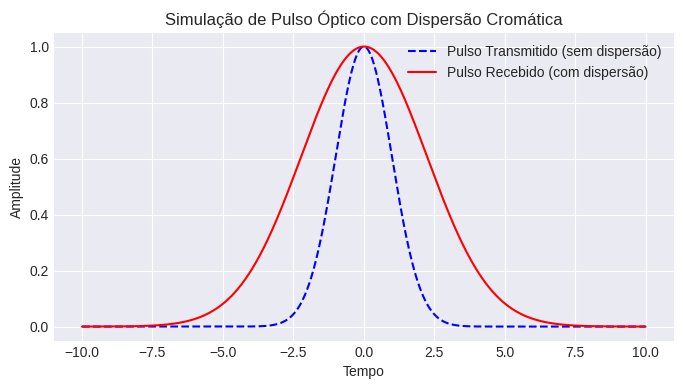

In [ ]:
# 3. Eixo temporal para a simulação.
# Tempo em unidades arbitrárias variando de -10 a 10.
t = np.linspace(-10, 10, 1000)

# 4. Gerar o pulso transmitido
amplitude = 1.0
# Largura do pulso original (antes da dispersão)
largura_pulso = 1.0
pulso_tx = pulso_gaussiano(t, amplitude, largura_pulso)

# 5. Definir a resposta do sistema (dispersão da fibra óptica)
# A dispersão vai "alargar" o pulso ao longo da fibra
largura_dispersao = 2.0
resposta_fibra = resposta_dispersao(t, largura_dispersao)

# 6. Realizar a convolução entre o pulso transmitido e a resposta da fibra (dispersão)
# Pulso recebido após a dispersão
pulso_rx = convolve(pulso_tx, resposta_fibra, mode='same')

# 7. Normalizar o pulso recebido
pulso_rx = pulso_rx / np.max(pulso_rx)

# 8. Visualizar os pulsos transmitido e recebido
plt.figure(figsize=(8, 4))
plt.plot(t, pulso_tx, label='Pulso Transmitido (sem dispersão)', color='blue', linestyle='--')
plt.plot(t, pulso_rx, label='Pulso Recebido (com dispersão)', color='red')
plt.title('Simulação de Pulso Óptico com Dispersão Cromática')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

>Neste exemplo, usamos a convolução para simular como um pulso óptico sofre dispersão cromática ao passar por uma fibra óptica. A convolução nos permite calcular a forma final do pulso recebido, considerando os efeitos de dispersão da fibra.
Esse tipo de análise é muito importante em comunicações ópticas, pois a dispersão cromática pode limitar a taxa de transmissão de dados e a distância máxima de transmissão sem regeneração do sinal.

In [ ]:
if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .

In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
from scipy.constants import c, h, k, e
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt

from optic.utils import parameters
from optic.comm.modulation import modulateGray
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm, lowPassFIR
from optic.plot import eyediagram
from optic.models.devices import mzm, iqm, photodiode

In [ ]:
def Tx_DSP(SpS, modulation, M, fator_size, pulso_type):
  """

  Esta parte contém todos os passos referente a primeira parte de toda simulação,
  que é a Tx_DSP e ela retorna o sinal formatado no pulso.

  Parameters:

    - SpS: int -> Taxa de amostragem
    - modulation: string -> tipo de modulação usada: OOK, PAM, QAM
    - M: int -> Ordem da modulação
    - fator_size: int -> Fator de multiplicação usado para gerar os sinais, se OOK será o tamanho da Samples.
    - pulso_type: string -> Modelo do pulso que será modelado

  Returns:
    - sigTX: np.array -> Sinal formatado no pulso preparado para modulação MZM
    - symbUp: np.array -> Amostras de simbolos
    - bitsTx: np.array -> Bits gerados

  """

  # Determinando o tamanho para gerar os bits
  if (modulation == "OOK"):
    size = (fator_size)
    M = 2
  elif (modulation == "pam"):
    size = int((fator_size*np.log2(M)))
  elif (modulation == "qam"):
    size = int((fator_size*np.log2(M)))
  else:
    print("Modulação será OOK")
    size = (fator_size)
    M = 2

  # Gerandos os bits aleatorios.
  bitsTx = np.random.randint(2, size=size)

  # Mapeando os bits e transformando em sinais eletricos e Normalizando
  if (size == fator_size):
    symbTx = M*bitsTx-1
    symbtx = symbTx/np.sqrt(signal_power(symbTx))
  else:
    symbTx = modulateGray(bitsTx, M, modulation)
    symbtx = pnorm(symbTx)

  # Aumentando o numero de amostras e filtrando com o pulso.
  symbUp = upsample(symbtx, SpS)
  pulse = pulseShape(pulso_type,SpS)
  pulse = pulse/np.max(np.abs(pulse))
  sigTx = firFilter(pulse, symbUp)

  return sigTx, symbUp, bitsTx

In [ ]:
#######     Iniciando os Parametros default     #######

#######     Parametros de Simulacao
SpS = 32                                                                        # Taxa de amostragem, quantidade de amostra por simbolo
Rs  = 10e9                                                                      # Taxa de simbolos, largura de banda em (Hz)
Ts  = 1/Rs                                                                      # Periodo de simbolos em (s)
Fa  = 1/(Ts/SpS)                                                                # Frequencia de amostragem em (Hz)
Ta  = 1/Fa                                                                      # Periodo de amostragem em (s)

#######     Parametros da Modulação Optica
paramMZM = parameters()
paramMZM.Vpi = 2                                                                # Tensão π do modulador Mach-Zehnder (volts)
paramMZM.Vb = -paramMZM.Vpi/2                                                   # Tensão b do modulador Mach-Zehnder (volts)
Pi_dBm = 3                                                                      # Potência de entrada óptica no MZM (em dBm)

paramIQM = parameters()
paramIQM.Vpi = 2                                                                # Tensão π do modulador Mach-Zehnder (volts)
paramIQM.Vb = -paramIQM.Vpi                                                     # Tensão b do modulador Mach-Zehnder (volts)

#######     Parametros da geração de bits e inicio da Tx_DSP
# Obs.: Para modulação OOK, use M = 2
M = 2
modulation = "ook" #"pam" "qam"
fator_size = 10e3                                                               # Fator de multiplicação usado para gerar os sinais, se OOK será o tamanho da Samples.
pulso_type = "nrz"                                                              # Tipo do pulso que será gerado para modulação

sigTx, symbUp, bitsTx = Tx_DSP(SpS, modulation, M, int(fator_size), pulso_type)

#######     Modulação Optica        #######
Pi = 10**(Pi_dBm/10)*1e-3                                                       # potência de sinal óptico em W na entrada do MZM
Ai = np.sqrt(Pi)
if (modulation == "qam"):
  sigTxo = iqm(Ai, -0.5*(paramMZM.Vb)*sigTx, paramMZM)
else:
  sigTxo = mzm(Ai, -(paramMZM.Vb)*sigTx, paramMZM)

Modulação será OOK


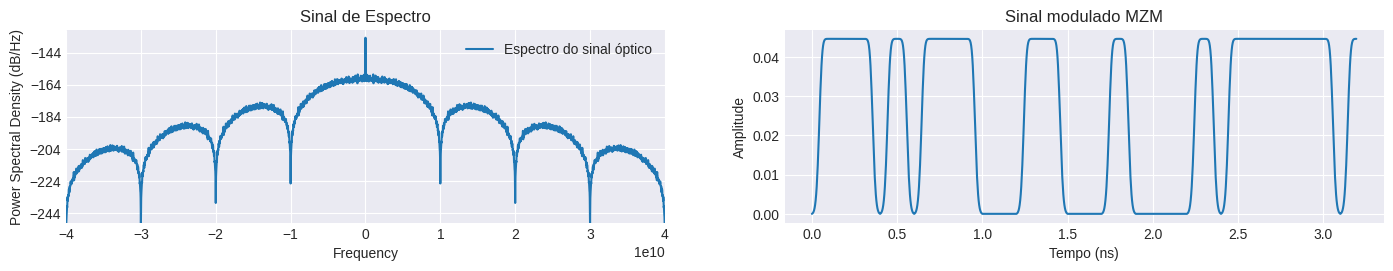

In [ ]:
# plota de graficos
# Parametros para a plotagem
t = np.arange(0, sigTxo.size)*(Ta/1e-9)
idX = np.arange(0,1023)

fig, axis = plt.subplots(1, 2, figsize=(17, 2.5))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].psd(np.abs(sigTxo)**2, Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal óptico")
axis[0].set_xlim(-4*Rs,4*Rs)
axis[0].set_ylim(-250,-130)
axis[0].set_title("Sinal de Espectro")
axis[0].legend(loc="best")

axis[1].plot(t[idX], np.abs(sigTxo[idX]))
axis[1].set_xlabel("Tempo (ns)")
axis[1].set_ylabel("Amplitude")
axis[1].set_title("Sinal modulado MZM")
axis[1].grid(True)

# diagrama de olho
#eyediagram(sigTx, sigTx.size - SpS, SpS, plotlabel = "Sinal Elétrico")
#eyediagram(np.abs(sigTxo)**2, sigTxo.size - SpS, SpS,  plotlabel = "Sinal Óptico")

In [ ]:
def SSF_Simetrico(sigTxo, L_fibra, D, alpha, lmbd, gamma, hz, Fa, NFFT):
  """

  Esta função descreve a propagação de um pulso e usa a equação de
  Schrödinger para simular dispersão β2, perdas α e efeito kerr γ.

  Parameters:
    - sigTxo: np.array -> Sinal modulado
    - L_fibra: float -> Comprimento da fibra
    - D: float -> Parâmetro de dispersão
    - alpha: float -> Coeficiente de atenuação (dB/Km)
    - lmbd: float -> Comprimento de onda
    - gamma: float -> Coeficiente do efeito kerr
    - h: float -> Comprimento de cada interação
    - Fa: float -> Frequência de amostragem
    - NFFT: int -> Número de pontos do FFT

  Returns:
    - sigRx: np.array -> Sinal recebido apos a propagação no receptor
    - z: np.array -> Distância percorrida

  """
  alpha = 1e-3*alpha/(10*np.log10(np.exp(1)))                                   # Converte para linear Nepers/m
  beta2 = -(D*lmbd**2)/(2*np.pi*c)                                              # Segunda derivada da constante de propagação
  omega = 2*np.pi*Fa*np.fft.fftfreq(NFFT)                                       # Frequência de operação
  z = 0

  ####### Iniciando a manipulação da equação de Schrödinger
  sigRx = np.fft.fft(sigTxo)

  while z <= L_fibra:
    # Primeiro passo - operador linear
    sigRx = sigRx*np.exp(-alpha*(hz/2)+1j*(beta2/2)*(omega**2)*(hz/2))          # A(z + h , t) = A(z,t)e^{\frac{h}{2}\hat{D}}

    # Operador não linear
    sigRx = np.fft.ifft(sigRx)                                                  # Transformada inversa de Fourier
    sigRx = sigRx*np.exp(1j*gamma*(np.abs(sigRx)**2)*hz)                        # A(z + h , t) = A(z,t)e^{h\hat{N}}

    #Segundo passo - operador linear
    sigRx = np.fft.fft(sigRx)
    sigRx = sigRx*np.exp(-alpha*(hz/2)+1j*(beta2/2)*(omega**2)*(hz/2))          # A(z + h , t) = A(z,t)e^{\frac{h}{2}\hat{D}}

    z = z + hz                                                                  # Atualiza a distância percorrida

  sigRx = np.fft.ifft(sigRx)                                                    # Transformada inversa de Fourier

  return sigRx, z

In [ ]:
def edfa_lin(sigRx, gain, NF, Fc, Fa):
  """
  Esta função modela de forma simplificada o efeito de um amplificador óptico EDFA,
  retornando o sinal amplificado com a adição de ruído ASE (Amplified Spontaneous Emission).

  Parameters:
    - sigRx: np.array -> Sinal recebido após os calculos das imperfeições
    - gain: float -> Ganho óptico total do amplificador (em dB)
    - NF: int ->Figura de ruído do amplificador (em dB)
    - Fc: float -> Frequência central do sinal óptico (em Hz)
    - Fa: float -> Frequência de amostragem do sinal (em Hz)

  Returns:
    - sigRxo: np.array -> Sinal amplificado com ruído ASE adicionado

  """
  gain = 10**(gain/10)                                                          # Converte para linear
  NF = 10**(NF/10)                                                              # Converte para linear
  nsp = (gain*NF -1)/(2*(gain -1))                                              # Fator de emissão espontânea (ou fator de inversão de população)
  # h constante de planck que foi importada
  s_ase = (gain -1)*nsp*h*Fc                                                    # Densidade espectral do ruído de emissão espontânea amplificada (ASE)
  pt_noise = s_ase * Fa                                                         # Potência do ruído
  mean_noise = 0                                                                # Média do ruído
  noise    = np.random.normal(mean_noise, np.sqrt(pt_noise), sigRx.shape) + 1j*np.random.normal(mean_noise, np.sqrt(pt_noise), sigRx.shape)        # ruido gerado pelo EDFA

  sigRx = sigRx*gain + noise                                                   # Sinal com ruído

  return sigRx

In [ ]:
##############      Processos no Canal Optico     ##############

#######     Parametros da fibra
L_fibra = 40e3                                                                  # Comprimento da fibra 40m
D     = 17e-6                                                                   # Parâmetro de dispersão s/(m²)
alpha = 0.2                                                                     # parametro para perdas dB/Km
lmbd   = 1550e-9                                                                # comprimento de onda
gamma = 1.22e-3                                                                 # parametro do efeito kerr W-1/m
hz    = 0.09e3                                                                   # comprimento de cada interação m
NFFT  = len(sigTxo)                                                             # numero de pontos do FFT

# Chamando a função que irá simular as dispersões, perdas e efeitos Kerr
sigRx, z = SSF_Simetrico(sigTxo, L_fibra, D, alpha, lmbd, gamma, hz, Fa, NFFT)

# Chamando a função que irá colocar os ruídos gerados por um amplificador EDFA.
Fc = c/lmbd                                                                     # Calcula a frequência central
gain = alpha * z * 1e-3                                                         # Transformando dB/km em (gain)dB
sigRx = edfa_lin(sigRx, gain, 12, Fc, Fa)                                       # Aplicando o ganho

# Calculando as tranformadas para comparar seus espectros
sigTxo_FFT = np.fft.fftshift(np.fft.fft(sigTxo)) / NFFT
sigRx_FFT = np.fft.fftshift(np.fft.fft(sigRx)) / NFFT
sigTxo_Px  = np.abs(sigTxo_FFT)**2
sigRx_Px  = np.abs(sigRx_FFT)**2
freq = np.fft.fftshift(np.fft.fftfreq(len(sigRx_FFT), Ta))

Potência do sinal Tx (em dBm) = -0.00 dBm
Potência do sinal Rx (em dBm) = 0.01 dBm


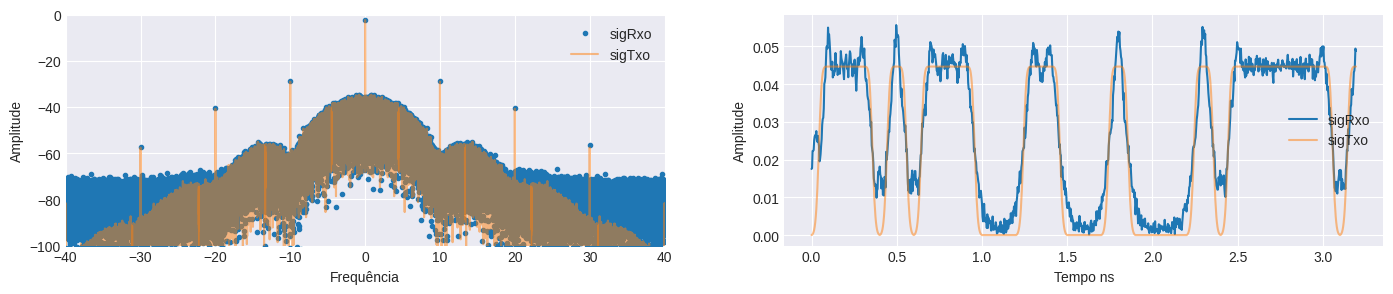

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(17,3))
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigRx_Px), ".", label = "sigRxo")
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigTxo_Px), alpha = 0.5, label = "sigTxo")
axs[0].set_ylabel("Amplitude")
axs[0].set_xlabel("Frequência")
axs[0].set_xlim(-4e-9*Rs,4e-9*Rs)
axs[0].set_ylim(-100,0)
axs[0].grid(True)
axs[0].legend(loc = "best")

axs[1].plot(t[idX], np.abs(sigRx[idX]), label = "sigRxo")
axs[1].plot(t[idX], np.abs(sigTxo[idX]), label = "sigTxo", alpha= 0.5)
axs[1].set_xlabel("Tempo ns")
axs[1].set_ylabel("Amplitude")
axs[1].grid(True)
axs[1].legend(loc = "best")

print("Potência do sinal Tx (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigTxo_Px)/1e-3)))
print("Potência do sinal Rx (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigRx_Px)/1e-3)))

In [ ]:
def receptor(bits, B, Fa, sigRxo, Ip, Is, It):

  # Gerando um filtro passa-baixa
  N = 8001
  h = lowPassFIR(B, Fa, N, typeF="rect")

  # calculando as correntes na simulação SNR
  Ipft  = firFilter(h, Ip)
  Isft  = firFilter(h, Is)
  Itft  = firFilter(h, It)

  SNR = np.var(Ipft)/(np.var(Isft) + np.var(Itft))

  # captura amostras no meio dos intervalos de sinalização
  sigRxo  = sigRxo[0::SpS]
  sigRxo = pnorm(sigRxo)

  I1 = np.mean(sigRxo[bits==1])                                                 # valor médio de I1
  I0 = np.mean(sigRxo[bits==0])                                                 # valor médio de I0
  σ1 = np.std(sigRxo[bits==1])                                                  # desvio padrão σ1 de I1
  σ0 = np.std(sigRxo[bits==0])                                                  # desvio padrão σ0 de I0
  Id = (σ1*I0 + σ0*I1)/(σ1 + σ0)                                                # limiar de decisão ótimo
  Q  = (I1-I0)/(σ1 + σ0)                                                        # fator Q, razão entre a separação dos níveis médios do sinal,

  # Aplica a regra de decisão ótima
  bitsRx = np.empty(bits.size)
  bitsRx[sigRxo>  Id] = 1
  bitsRx[sigRxo<= Id] = 0

  discard = 500                                                                 # Discarta as 500 primeiras amostras
  err = np.logical_xor(bitsRx[discard:bitsRx.size-discard], bits[discard:bits.size-discard])
  BER = np.mean(err)

  return err, BER, sigRxo, SNR, h

In [ ]:
##############      Processos no Canal Optico     ##############

# parâmetros do receptor
Tc = 25                                                                         # temperatura em Celsius
B  = Rs                                                                         # banda do receptor em Hz
Rd  = 0.85                                                                      # responsividade em A/W
Id = 5e-9                                                                       # corrente de escuro em nA
RL = 50                                                                         # Resistor de carga do circuito. em Ohms
Pin = (np.abs(sigRx)**2).mean()                                                # Potência óptica média média recebida

# fotocorrente livre de ruído
Ip = Rd*np.abs(sigRx)**2

# Gerando os ruidos // e constante elementary charge /// k constante de Boltzmann
σ2_s = 2*e*(Rd*Pin + Id)*B                                                      # Cálculo do ruído de disparo (shot noise)
T = Tc + 273.15
σ2_T = 4*k*T*B/RL                                                               # Cálculo do ruído térmico (thermal noise)

# adiciona ruído do receptor p-i-n aos sinais
Is = np.random.normal(0, np.sqrt(Fa*(σ2_s/(2*B))), Ip.size)
It = np.random.normal(0, np.sqrt(Fa*(σ2_T/(2*B))), Ip.size)

# Organizando os paramentros em uma função.
paramPD = parameters()
paramPD.Rd = Rd                                                                 # responsividade em A/W
paramPD.Tc = Tc                                                                 # temperatura em Celsius
paramPD.Id = Id                                                                 # corrente de escuro em A
paramPD.RL = RL                                                                 # RL em Ohms
paramPD.B = B                                                                   # Largura de banda Hz
paramPD.Fs = Fa
paramPD.ideal = False
sigRxo = photodiode(sigRx, paramPD)
I_eye = sigRxo.copy()
I_eye = pnorm(I_eye)
I_eye = I_eye[500*SpS:I_eye.size-500*SpS]

err, BER, sigRxo, SNR, h = receptor(bitsTx, B, Fa, sigRxo, Ip, Is, It)

Potencia do sinal modulado MZM= -0.00 dBm
SNR = 50.07 dB 

Total de erros contados = 0  
BER = 0.00e+00  


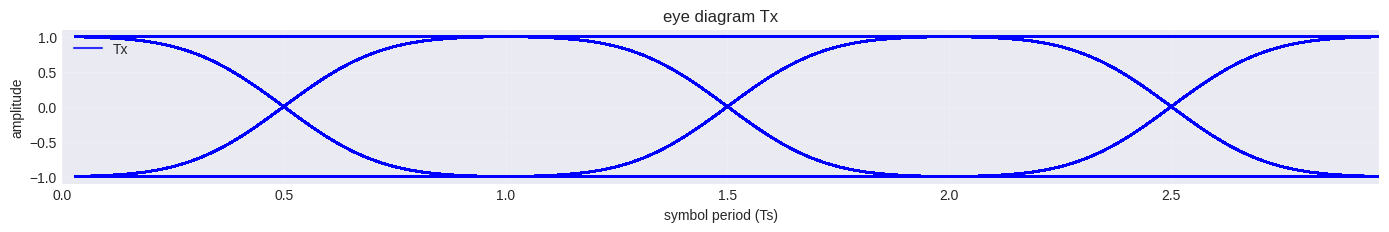

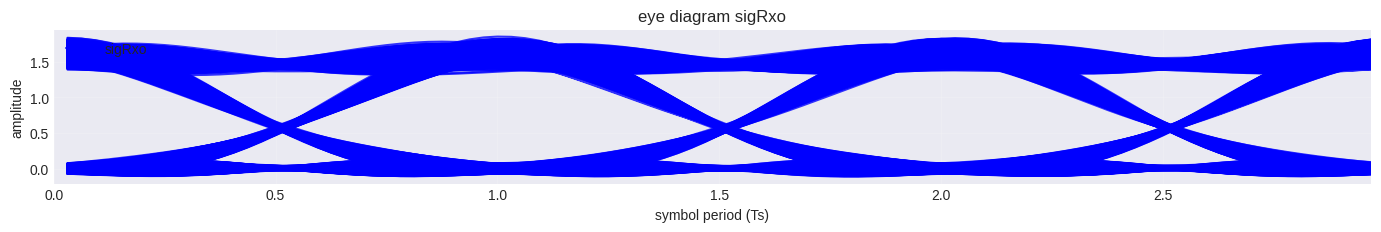

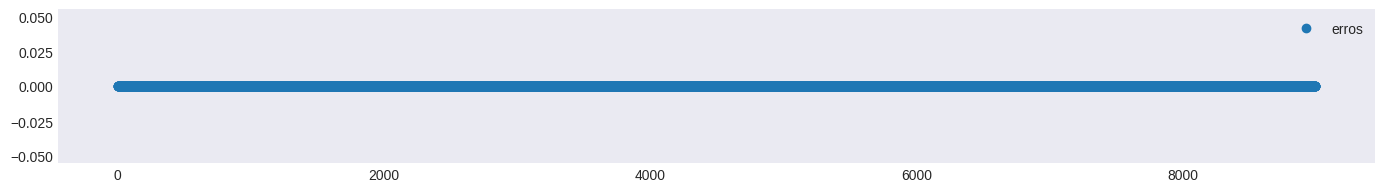

In [ ]:
print("Potencia do sinal modulado MZM= %.2f dBm"%(10*np.log10(signal_power(sigTxo)/1e-3)))
print("SNR = %.2f dB \n"%(10*np.log10(SNR)))
print("Total de erros contados = %d  "%(err.sum()))
print("BER = %.2e  "%(BER))

eyediagram(sigTx,  sigTx.size - SpS, SpS, plotlabel = "Tx")
eyediagram(I_eye, sigTx.size - SpS, SpS, plotlabel = "sigRxo")

plt.figure()
plt.plot(err,"o", label = "erros")
plt.legend()
plt.grid()